In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

from jjmodel.funcs import SFR
from jjmodel.input_ import p, a, inp



Parameter file(s) : ok.
Number of parameters =  66 , among them technical =  7

 p(run_mode=0, out_dir='new_metgrid', out_mode=1, nprocess=4, Rsun=8.275, zsun=20, zmax=2000, dz=5, sigmad=29.3, sigmat=4.9, sigmag1=2.0, sigmag2=11.0, sigmadh=51.9, sigmash=0.47, td1=0, td2=7.8, dzeta=0.8, eta=5.6, pkey=1, tt1=0.1, tt2=4, gamma=2, beta=3.5, imfkey=0, a0=1.31, a1=1.5, a2=2.88, a3=2.28, m0=0.49, m1=1.43, m2=6.0, dFeHdt=0, n_FeHdt=1, fehkey=0, FeHd0=-0.7, FeHdp=0.29, rd=0.34, q=-0.72, FeHt0=-0.94, FeHtp=0.04, rt=0.77, t0=0.97, FeHsh=-1.5, dFeHsh=0.4, n_FeHsh=5, alpha=0.375, sige=26.0, sigt=45, sigdh=140, sigsh=100, sigmap=array([3.5, 1.3]), tpk=array([10. , 12.5]), dtp=array([0.7 , 0.25]), sigp=array([26.3, 12.6]))

Parameters checked: 0 Reminders, 0 Warnings, 0 Errors.

Configuration finished:  0h 0m 0.0s


In [2]:
tp = 13
tr = 0.025

t = np.arange(tr/2,tp+tr/2,tr)


In [3]:

sfr = SFR()

# Default
SFRd0, _, _ = sfr.sfrd_sj21_multipeak(
    tp,
    tr,
    t,
    0.83,  # dzeta
    5.6,   # eta
    0,     # td1, fixed
    7.8,   # td2
    29.3,  # sigmad
    np.array([3.5,1.3]),   # sigmap
    np.array([10.0,12.5]), # tpk
    np.array([0.7,0.25]),  # dtp
    g=inp['gd0']
) 


In [4]:
# Varied
SFRd, _, _ = sfr.sfrd_sj21_multipeak(
    tp,
    tr,
    t,
    0.81,  # dzeta, larger value -> smaller old peak
    1.0,   # eta, smaller value -> smaller old peak
    0,     # td1, fixed
    7.8,   # td2, larger value -> smaller old peak
    29.3,  # sigmad, fixed
    np.array([1e-5,1e-5]), # sigmap
    np.array([10.0,12.5]), # tpk
    np.array([0.7,0.25]),  # dtp
    g=inp['gd0']
) 

Text(0, 0.5, 'SFR, Msun / yr / pc2')

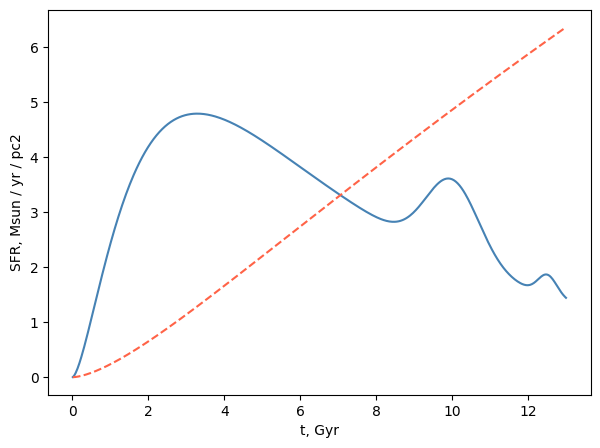

In [5]:
fig, ax = plt.subplots(1,1,figsize=(7,5))
ax.plot(t,SFRd0,c='steelblue')
ax.plot(t,SFRd,ls='--',c='tomato')
ax.set_xlabel('t, Gyr')
ax.set_ylabel('SFR, Msun / yr / pc2')


In [6]:
def interactive_sfr(
    dzeta=0.83,
    eta=5.6,
    td2=7.8,
    sigmap0=3.5,
    sigmap1=1.3
):
    sigmap = np.array([sigmap0, sigmap1])

    SFRd0, _, _ = sfr.sfrd_sj21_multipeak(
        tp,
        tr,
        t,
        dzeta,
        eta,
        0.0,         # td1 fixed
        td2,
        29.3,        # sigmad fixed
        sigmap,
        np.array([10.0,12.5]),
        np.array([0.7,0.25]),
        g=inp['gd0']
    )

    plt.figure(figsize=(7,4))
    plt.plot(t, SFRd0, lw=2)
    plt.xlabel("t")
    plt.ylabel("SFR")
    plt.title("SFR with interactive parameters")
    plt.grid(alpha=0.3)
    plt.show()


In [ ]:
interact(
    interactive_sfr,
    dzeta=FloatSlider(0.83, min=0.01, max=2.0, step=0.1),
    eta=FloatSlider(5.6, min=0.01, max=20.0, step=0.1),
    td2=FloatSlider(7.8, min=0.01, max=20.0, step=0.1),
    sigmap0=FloatSlider(3.5, min=0.01, max=10.0, step=0.1),
    sigmap1=FloatSlider(1.3, min=0.01, max=10.0, step=0.1),
)

interactive(children=(FloatSlider(value=0.83, description='dzeta', max=2.0, min=0.01), FloatSlider(value=5.6, …

<function __main__.interactive_sfr(dzeta=0.83, eta=5.6, td2=7.8, sigmap0=3.5, sigmap1=1.3)>